In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

In [2]:
data = yf.download("BB", start="2024-01-01", end="2026-01-01", auto_adjust=True)
print(data)

price = data["Close"].squeeze().dropna()

[*********************100%***********************]  1 of 1 completed

Price      Close  High   Low  Open   Volume
Ticker        BB    BB    BB    BB       BB
Date                                       
2024-01-02  3.43  3.51  3.39  3.50  6794900
2024-01-03  3.33  3.40  3.32  3.40  8024100
2024-01-04  3.25  3.33  3.23  3.32  6353300
2024-01-05  3.26  3.30  3.23  3.23  3961500
2024-01-08  3.23  3.30  3.19  3.27  7478500
...          ...   ...   ...   ...      ...
2025-12-24  3.99  4.00  3.94  3.96  2241500
2025-12-26  3.97  3.98  3.90  3.96  4794800
2025-12-29  3.88  3.99  3.86  3.92  5517900
2025-12-30  3.79  3.88  3.78  3.87  7408900
2025-12-31  3.79  3.87  3.76  3.79  8297200

[502 rows x 5 columns]


In [3]:
log_return = np.log(price / price.shift(1)).dropna()

df = pd.concat([price, log_return], axis=1)
df.columns = ["price", "log_return"]
df = df.dropna()

In [4]:
threshold = 0.03

df["jump"] = (np.abs(df["log_return"]) > threshold).astype(int)

jump_times = df.index[df["jump"] == 1]

print(len(jump_times))

127


In [5]:
jump_dates = pd.to_datetime(jump_times)
inter_arrivals = jump_dates.to_series().diff().dropna().dt.days

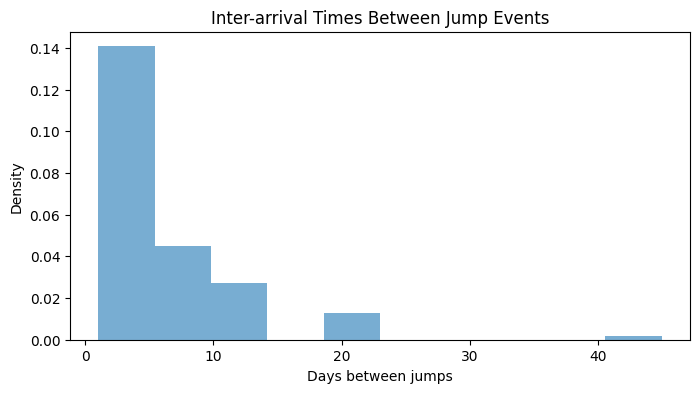

In [6]:
plt.figure(figsize=(8,4))

plt.hist(inter_arrivals, bins=10, density=True, alpha=0.6)

plt.title("Inter-arrival Times Between Jump Events")
plt.xlabel("Days between jumps")
plt.ylabel("Density")

plt.show()

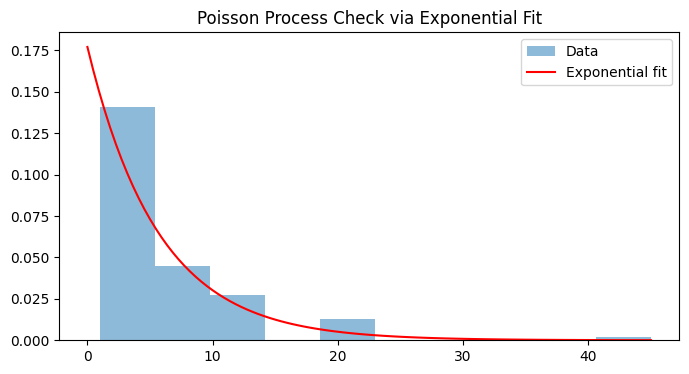

In [7]:
lambda_hat = 1 / inter_arrivals.mean()

x = np.linspace(0, inter_arrivals.max(), 100)
pdf = lambda_hat * np.exp(-lambda_hat * x)

plt.figure(figsize=(8,4))

plt.hist(inter_arrivals, bins=10, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r', label="Exponential fit")

plt.title("Poisson Process Check via Exponential Fit")
plt.legend()

plt.show()

In [8]:
t = np.array((jump_dates - jump_dates.min()).days)

In [9]:
def hawkes_loglik(params, t):
    mu, alpha, beta = params
    
    if mu <= 0 or alpha < 0 or beta <= 0:
        return np.inf
    
    n = len(t)
    ll = 0
    
    for i in range(1, n):
        past = t[:i]
        intensity = mu + np.sum(alpha * np.exp(-beta * (t[i] - past)))
        ll += np.log(intensity)
    
    compensator = mu * t[-1] + (alpha / beta) * np.sum(
        1 - np.exp(-beta * (t[-1] - t))
    )
    
    return -(ll - compensator)

In [10]:
init = np.array([0.1, 0.5, 1.0])

In [11]:
from scipy.optimize import minimize

result = minimize(hawkes_loglik, init, args=(t,), method="Nelder-Mead")

mu_hat, alpha_hat, beta_hat = result.x
mu_hat, alpha_hat, beta_hat

(np.float64(0.1769660262257716),
 np.float64(7.003542943604476e-10),
 np.float64(1.1977086565001382))

In [12]:
print("mu (baseline):", mu_hat)
print("alpha (self-excitation):", alpha_hat)
print("beta (decay):", beta_hat)

mu (baseline): 0.1769660262257716
alpha (self-excitation): 7.003542943604476e-10
beta (decay): 1.1977086565001382
